# Metacatalog NED-LVS cross-match

Cross-match the OVRO-LWA metacatalog against the latest [NED Local Volume Sample](https://ned.ipac.caltech.edu/NED::LVS/) (Cook et al. 2023).

Choose a metacatalog subset in the config cell before cross-matching. Matching uses **centroid position uncertainty** (`E_RA`/`E_DEC` when present, else `cluster_jitter_rms_deg`) scaled by `POSITION_SIGMA_SCALE` (default 3σ), not beam width. NED-LVS galaxies above `MAX_REDSHIFT` are excluded.

**Primary metric:** fraction of selected metacatalog rows with a NED-LVS galaxy within the scaled centroid error.

**SFR–radio plot:** unique matches only (`n_nedlvs == 1`); converts highest-frequency LWA flux to `nu*L_nu` vs NED-LVS SFR.

**Run cells in order.**

In [1]:
from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog, resolve_metacatalog_path
from lwa_catalog.analyze import (
    NedlvsMatchConfig,
    build_sfr_radio_luminosity_table,
    load_nedlvs_catalog,
    match_catalog_to_nedlvs,
    select_metacatalog,
    select_unique_nedlvs_matches,
    summarize_nedlvs_match,
)
from lwa_catalog.constants import (
    DEFAULT_QUALITY_FLAG_MASK,
    NEDLVS_DEFAULT_MAX_REDSHIFT,
    NEDLVS_DEFAULT_PATH,
)

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75")
NEDLVS_PATH = NEDLVS_DEFAULT_PATH
QUALITY_FLAG_MASK = DEFAULT_QUALITY_FLAG_MASK  # 247; set None to keep all rows

# Metacatalog subset before cross-match:
#   "full" | "blue" | "quality_all_clear" | "query"
METACATALOG_SELECTION = "blue"
METACATALOG_QUERY = "Peak_flux > 1.0"  # used only when METACATALOG_SELECTION == "query"

# Cross-match: sep <= POSITION_SIGMA_SCALE * sqrt(sigma_meta^2 + sigma_ned^2)
POSITION_SIGMA_SCALE = 3.0
MAX_REDSHIFT = NEDLVS_DEFAULT_MAX_REDSHIFT  # None to disable

layout = CatalogLayout(CATALOG_DIR)
config = NedlvsMatchConfig(
    catalog_path=NEDLVS_PATH,
    position_sigma_scale=POSITION_SIGMA_SCALE,
    max_redshift=MAX_REDSHIFT,
)

print("CATALOG_DIR =", layout.root.resolve())
print("metacatalog path =", resolve_metacatalog_path(layout))
print("QUALITY_FLAG_MASK =", QUALITY_FLAG_MASK)
print("NEDLVS_PATH =", Path(NEDLVS_PATH).resolve())
print("METACATALOG_SELECTION =", METACATALOG_SELECTION)
print("POSITION_SIGMA_SCALE =", POSITION_SIGMA_SCALE)
print("MAX_REDSHIFT =", MAX_REDSHIFT)

CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75
NEDLVS_PATH = /fast/claw/NEDLVS_current.fits
METACATALOG_SELECTION = blue
RUN_LST_MERGED_PASS = False


## Load and select metacatalog

In [2]:
metacatalog = read_metacatalog(layout, quality_mask=QUALITY_FLAG_MASK)
selected_meta = select_metacatalog(
    metacatalog,
    selection=METACATALOG_SELECTION,
    layout=layout,
    query=METACATALOG_QUERY,
)

print(f"metacatalog rows: {len(metacatalog)}")
print(f"selected rows ({METACATALOG_SELECTION}): {len(selected_meta)}")
print(f"quality_flag present: {'quality_flag' in metacatalog.columns}")

metacatalog rows: 106426
selected rows (blue): 102609


## Load NED-LVS

Loads ~2.1M rows from the FITS table (takes ~15–30 s on lwacalim09).

In [3]:
nedlvs = load_nedlvs_catalog(NEDLVS_PATH)
print(f"NED-LVS rows: {len(nedlvs):,}")
print(f"rows with Diam: {(nedlvs['Diam_arcsec'] > 0).sum():,}")
nedlvs.head()

NED-LVS rows: 2,103,732
rows with Diam: 1,701,193


,objname,RA,DEC,objtype,z,DistMpc,Mstar,SFR_hybrid,SFR_W4,Diam_arcsec,BMAJ
0,b'WISEA J120155.41+623831.1',180.480897,62.641997,b'G',-0.000509,0.0,NaN,NaN,NaN,NaN,0.005556
1,b'DESI J252.3925+33.8869',252.392549,33.886965,b'G',-0.000409,0.0,NaN,NaN,NaN,NaN,0.005556
2,b'WISEA J090812.84+514023.6',137.053538,51.673233,b'IrS',-0.000102,0.0,NaN,NaN,NaN,NaN,0.005556
3,b'DESI J194.2665+32.1772',194.266570,32.177269,b'G',-0.000922,0.0,NaN,NaN,NaN,NaN,0.005556
4,b'SDSS J120327.61-015758.7',180.865007,-1.966329,b'G',-0.000043,0.0,NaN,NaN,NaN,NaN,0.005556


## Cross-match against NED-LVS

In [4]:
result = match_catalog_to_nedlvs(selected_meta, nedlvs=nedlvs, config=config)
print(summarize_nedlvs_match(result))

LWA target rows:                102609
NED-LVS footprint (Dec box):    1923838
Meta matched (>=1 NED-LVS):      79316
Meta with NED-LVS host:         0.773
NED-LVS matched (>=1 meta):     525904
NED-LVS recovery:               0.273
NED-LVS over-split (n_meta>1):   69792
Meta multi-NED-LVS (n>1):        62074
Max NED-LVS hits per meta:        7212


## Diagnostics

In [5]:
meta_flags = result.meta_flags
nedlvs_flags = result.nedlvs_flags

print("NED-LVS hits per meta (value_counts):")
display(meta_flags["n_nedlvs"].value_counts().sort_index())

print("\nMeta rows with no NED-LVS host (first 20):")
display(meta_flags.loc[~meta_flags["matched"]].head(20))

oversplit_cols = [
    c
    for c in [
        "nedlvs_pos",
        "RA",
        "DEC",
        "objname",
        "DistMpc",
        "n_meta",
        "meta_ids",
        "oversplit",
    ]
    if c in nedlvs_flags.columns
]
print("\nOver-split NED-LVS rows (multiple meta matches, first 20):")
display(nedlvs_flags.loc[nedlvs_flags["oversplit"], oversplit_cols].head(20))

NED-LVS hits per meta (value_counts):


n_nedlvs
0       23293
1       17242
2       12839
3        9256
4        6968
        ...  
636         1
771         1
2798        1
3502        1
7212        1
Name: count, Length: 257, dtype: int64


Meta rows with no NED-LVS host (first 20):


,meta_id,RA,DEC,n_nedlvs,nedlvs_positions,matched
2,3,283.880459,1.421455,0,[],False
3,4,278.237177,-10.180164,0,[],False
4,5,270.055735,-23.309410,0,[],False
5,6,262.638596,-21.534439,0,[],False
10,52932,258.610079,-38.410699,0,[],False
12,52933,270.334609,-23.374664,0,[],False
13,13,283.137269,0.697587,0,[],False
15,15,287.779034,9.110626,0,[],False
16,16,265.089849,-30.958680,0,[],False
18,19,270.807016,-27.808885,0,[],False



Over-split NED-LVS rows (multiple meta matches, first 20):


,nedlvs_pos,RA,DEC,objname,DistMpc,n_meta,meta_ids,oversplit
13,13,196.358087,27.039326,b'WISEA J130525.94+270221.5',0.0,2,"[6209, 24473]",True
21,21,3.499192,-30.323964,b'SSTSL2 J001359.77-301926.1',0.0,2,"[14727, 17394]",True
23,23,15.201883,11.957589,b'SDSS J010048.45+115727.3',0.0,2,"[29214, 67681]",True
39,39,37.597864,0.386239,b'WISEA J023023.46+002311.7',0.0,2,"[13466, 84961]",True
40,40,218.977221,-1.818390,b'SDSS J143554.53-014906.2',0.0,2,"[20386, 58082]",True
161,161,235.187267,42.490985,b'DESI J235.1872+42.4909',0.0,2,"[45827, 101497]",True
179,179,56.503785,68.146760,b'WISEA J034600.90+680848.3',0.0,2,"[3875, 98866]",True
229,229,56.664837,68.159344,b'WISEA J034639.56+680933.6',0.0,2,"[3875, 98866]",True
235,235,278.564628,35.158982,b'WISEA J183415.44+350931.6',0.0,2,"[18906, 19469]",True
253,253,186.304862,13.025146,b'VCC 0779',0.0,3,"[60, 8336, 65996]",True


## NED-LVS recovery vs distance (unique matches only)

For each `DistMpc` threshold, recovery is the fraction of bijective NED-LVS matches (exactly one galaxy per meta row, and one meta row per galaxy) at or closer than that distance.

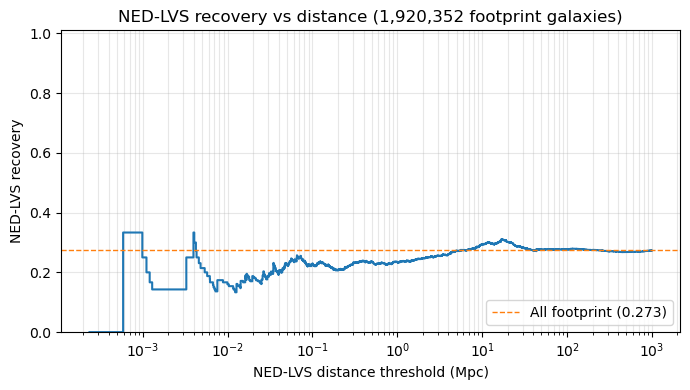

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from lwa_catalog.analyze import select_bijective_nedlvs_flags

bijective_ned = select_bijective_nedlvs_flags(result.meta_flags, result.nedlvs_flags)
bijective_pos = set(bijective_ned["nedlvs_pos"].astype(int).tolist())

footprint_dist = pd.to_numeric(result.nedlvs_footprint["DistMpc"], errors="coerce")
ok = np.isfinite(footprint_dist.to_numpy(dtype=float)) & (footprint_dist > 0)
dist_all = footprint_dist.loc[ok].to_numpy()
matched = np.array(
    [1 if pos in bijective_pos else 0 for pos in footprint_dist.loc[ok].index],
    dtype=int,
)
order = np.argsort(dist_all)
dist_all = dist_all[order]
matched = matched[order]

suffix_matched = np.cumsum(matched)
suffix_total = np.arange(1, len(dist_all) + 1, dtype=float)
recovery = suffix_matched / suffix_total
overall = float(suffix_matched[-1] / suffix_total[-1]) if len(dist_all) else float("nan")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dist_all, recovery, drawstyle="steps-post")
ax.axhline(
    overall,
    color="C1",
    ls="--",
    lw=1,
    label=f"Bijective recovery ({overall:.3f})",
)
ax.set_xscale("log")
ax.set_xlabel("NED-LVS distance threshold (Mpc)")
ax.set_ylabel("Bijective match fraction")
ax.set_ylim(0, 1.01)
ax.set_title(
    f"Unique-match recovery vs distance ({int(suffix_matched[-1]):,} bijective / "
    f"{len(dist_all):,} footprint galaxies)"
)
ax.legend(loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## SFR–radio luminosity relation (unique matches only)

Uses only meta rows with exactly one NED-LVS association (`n_nedlvs == 1`). For each pair with NED-LVS SFR and redshift, the highest-frequency positive `Peak_flux_{band}` is converted to `nu*L_nu` and plotted versus SFR.

In [7]:
unique_meta = select_unique_nedlvs_matches(result.meta_flags)
print(
    f"unique meta matches: {len(unique_meta):,} / {len(result.meta_flags):,} matched rows"
)

sfr_radio = build_sfr_radio_luminosity_table(
    selected_meta,
    result.nedlvs_footprint,
    result.meta_flags,
    unique_only=True,
)
print(f"unique pairs with SFR + radio luminosity: {len(sfr_radio)}")
display(sfr_radio.head())

matched galaxies with SFR + radio luminosity: 71660


,meta_id,objname,z,SFR,SFR_column,radio_band,radio_freq_hz,Peak_flux_jy,L_nu_erg_s_hz,nuL_nu_erg_s
0,52928,b'WISEA J091806.06-120438.8',0.052760,0.579917,SFR_W4,Blue,7.395688e+07,323.170494,2.284112e+34,1.689258e+42
1,8,b'WISEA J062730.66-055451.5',0.079209,4.108627,SFR_W4,Blue,7.395688e+07,40.950213,6.768072e+33,5.005455e+41
2,52929,b'NGC 1310',0.006021,0.237581,SFR_hybrid,Blue,7.395688e+07,59.836828,5.142632e+31,3.803330e+39
3,52930,b'3C 219',0.174565,24.507255,SFR_hybrid,Blue,7.395688e+07,54.260154,4.919369e+34,3.638212e+42
4,52931,b'WISEA J215557.36+380618.5',0.114950,3.057077,SFR_W4,Blue,7.395688e+07,52.690821,1.923370e+34,1.422465e+42


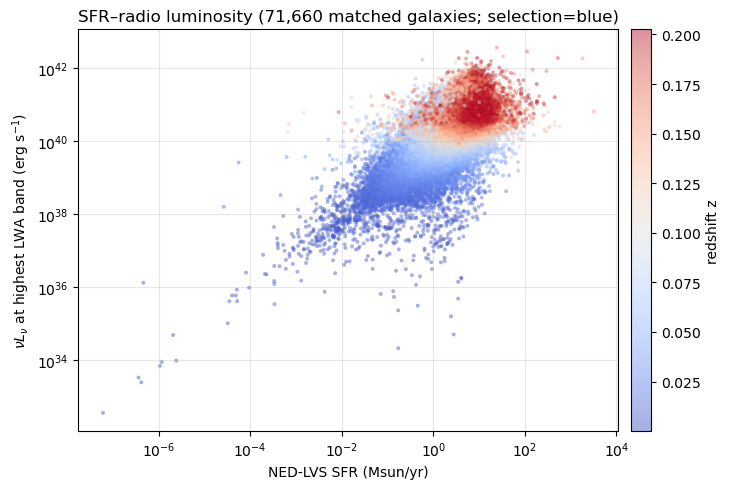

In [8]:
if sfr_radio.empty:
    print("No SFR–radio pairs to plot.")
else:
    fig, ax = plt.subplots(figsize=(7.5, 5))
    sc = ax.scatter(
        sfr_radio["SFR"],
        sfr_radio["nuL_nu_erg_s"],
        c=sfr_radio["z"],
        cmap="coolwarm",
        s=8,
        alpha=0.45,
        edgecolors="none",
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("redshift z")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("NED-LVS SFR (Msun/yr)")
    ax.set_ylabel(r"$\nu L_\nu$ at highest LWA band (erg s$^{-1}$)")
    ax.set_title(
        f"SFR–radio luminosity ({len(sfr_radio):,} unique matches; "
        f"selection={METACATALOG_SELECTION})"
    )
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()